# 선형회귀

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 단순선형회귀 모델 만들기

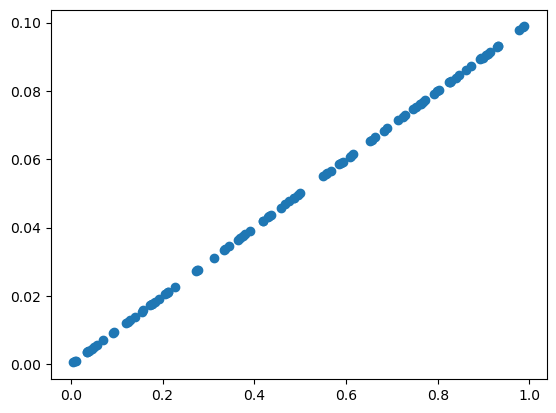

In [24]:
X = np.random.rand(100)
y = 0.2 * X * 0.5 # ax + b

plt.scatter(X, y)

In [4]:
def plt_prediction(pred, y):
    plt.figure(figsize=(8,6))
    plt.scatter(X, y, color='blue', label='Actual')
    plt.scatter(X, pred, color='orange', label='Prediction')
    plt.legend()
    plt.show()

In [25]:
# 경사하강법 y = wX + b에서 w를 결정
W = np.random.uniform(-1,1)
b = np.random.uniform(-1,1)
learning_rate = 0.5 # 임의 값

Epoch : 0, W : -0.1065, Error : 0.5132


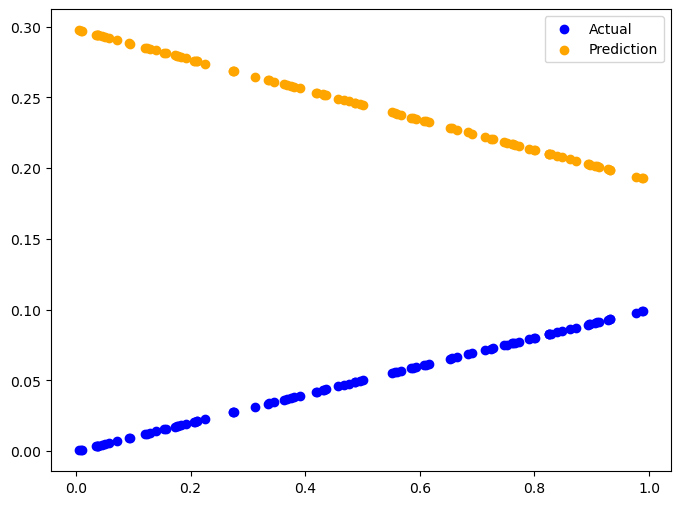

Epoch : 10, W : -0.0979, Error : 0.0543


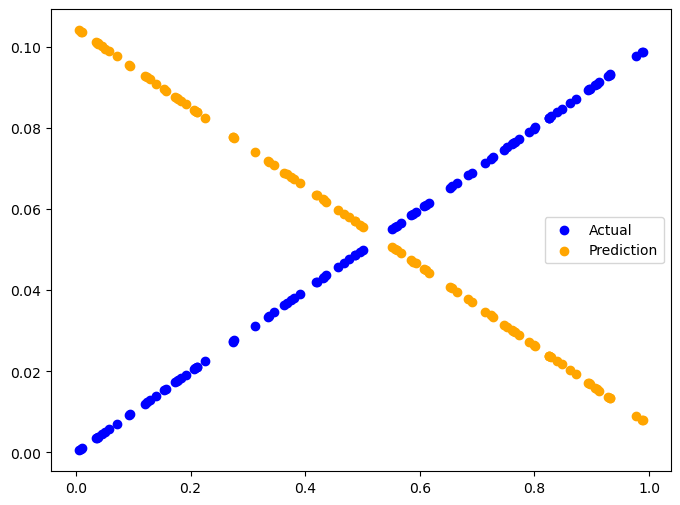

Epoch : 20, W : -0.0376, Error : 0.0377


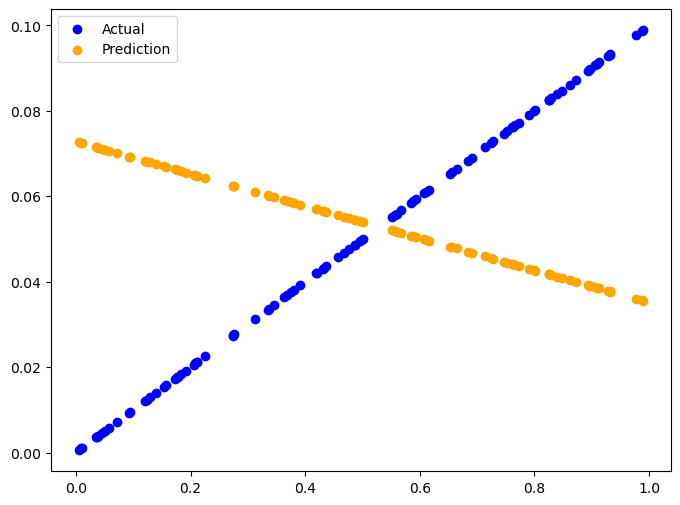

Epoch : 30, W : 0.0043, Error : 0.0263


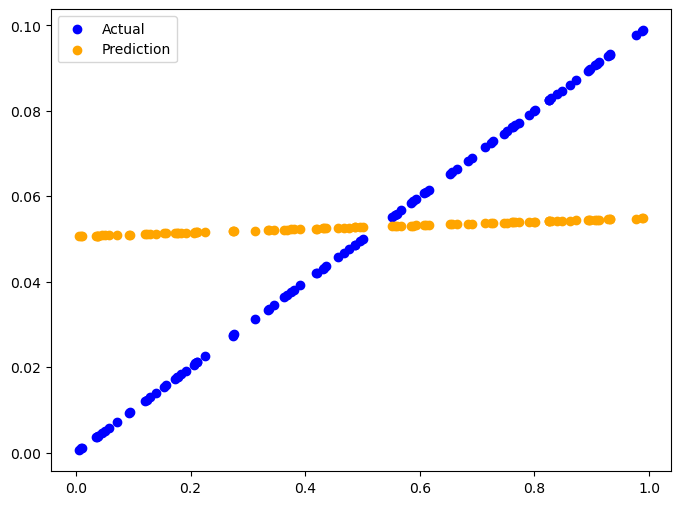

Epoch : 40, W : 0.0334, Error : 0.0183


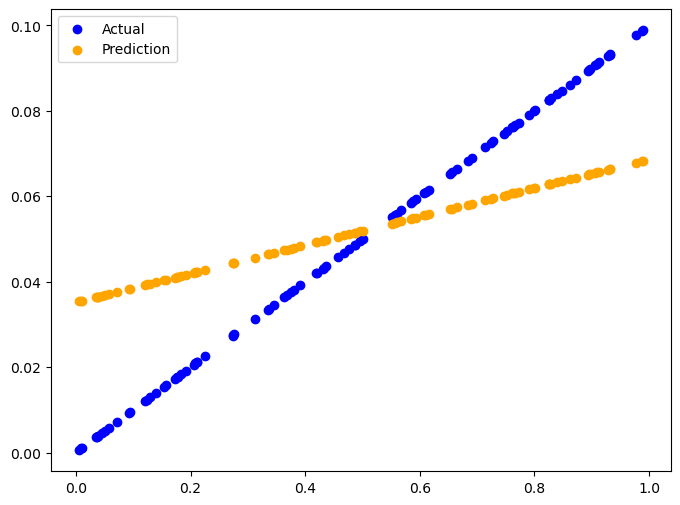

Epoch : 50, W : 0.0537, Error : 0.0127


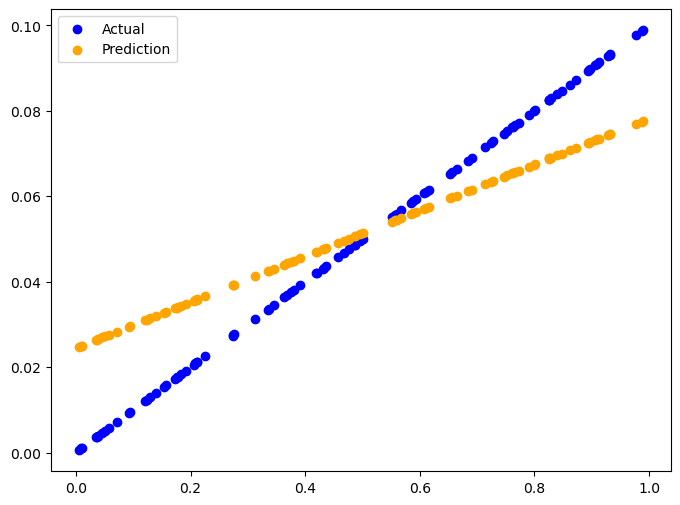

Epoch : 60, W : 0.0678, Error : 0.0088


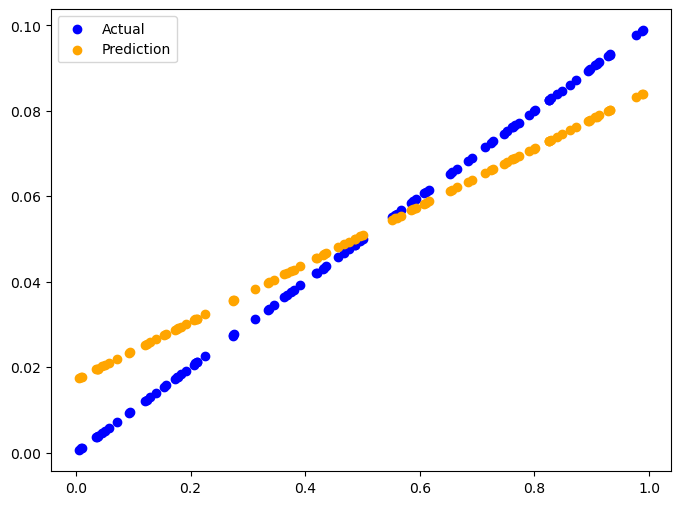

Epoch : 70, W : 0.0776, Error : 0.0061


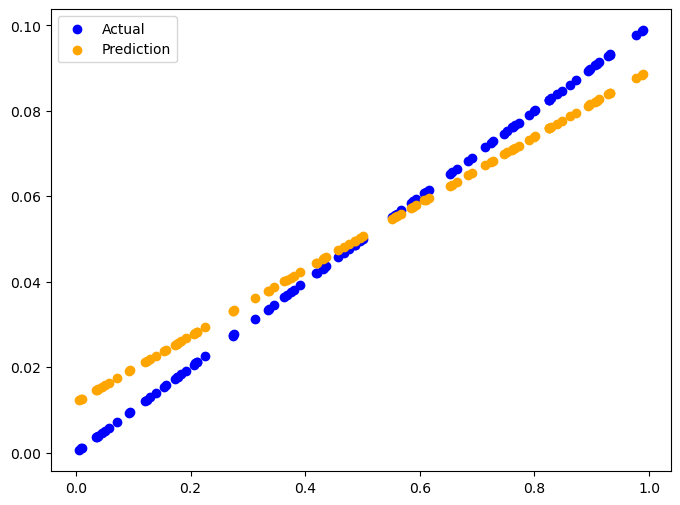

Epoch : 80, W : 0.0844, Error : 0.0043


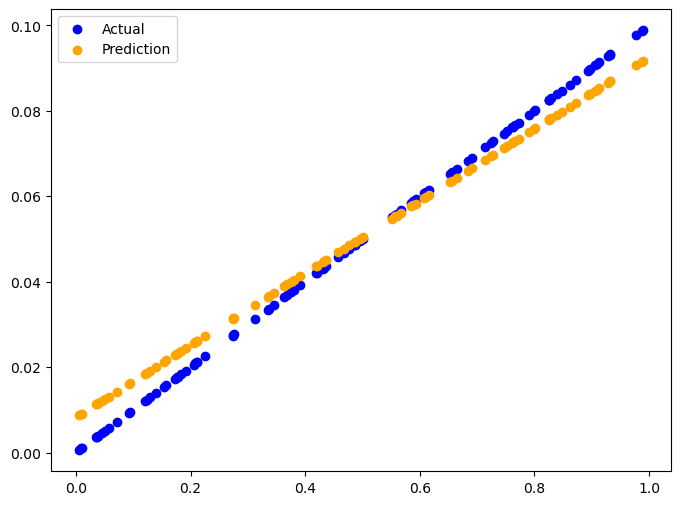

Epoch : 90, W : 0.0892, Error : 0.0030


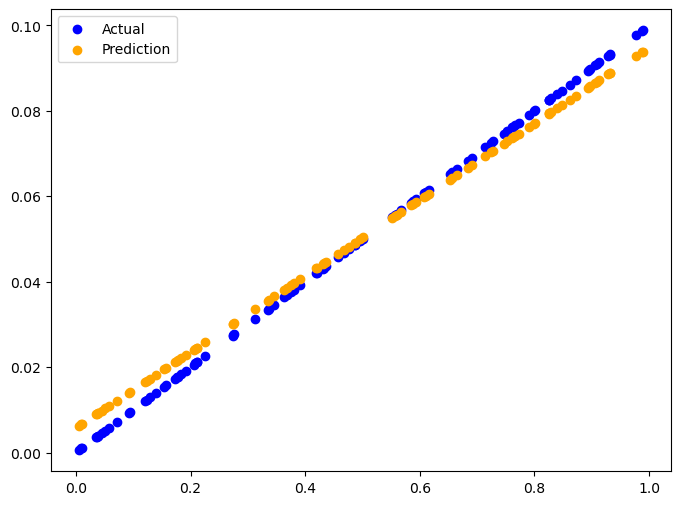

In [26]:
for epoch in range(100):
    y_pred = W * X + b
    error = np.abs(y_pred - y).mean()
    if error < 0.001:
        break
    W_descent = learning_rate * ((y_pred - y) * X).mean()
    b_descent = learning_rate * ((y_pred - y).mean())
    W -= W_descent
    b -= b_descent
    
    if epoch % 10 == 0:
        print(f"Epoch : {epoch}, W : {W:.4f}, Error : {error:.4f}")
        y_pred = W * X + b
        plt_prediction(y_pred, y)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [4]:
bostonDF = pd.read_csv('data/boston.csv')
bostonDF.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'target'],
      dtype='object')

In [24]:
X = bostonDF.drop('target', axis=1).values
y = bostonDF['target']
bostonDF.shape

(506, 14)

In [6]:
bostonDF.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=156)
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
y_pred[:3]

array([23.15424087, 19.65590246, 36.42005168])

In [15]:
# 평가
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

rmse, mse

(np.float64(4.158956107955705), np.float64(17.296915907902065))

In [9]:
# 결정계수
r2_score(y_test, y_pred)

np.float64(0.7572263323138934)

In [10]:
# 회귀식
# W0, W1
lr.intercept_, lr.coef_

(np.float64(40.99559517216439),
 array([-1.12979614e-01,  6.55124002e-02,  3.44366694e-02,  3.04589777e+00,
        -1.97958320e+01,  3.35496880e+00,  5.93713290e-03, -1.74185354e+00,
         3.55884364e-01, -1.42954516e-02, -9.20180066e-01,  1.03966156e-02,
        -5.66182106e-01]))

y = W0 + W1*X1 + W2*X2 + ... W13*X13

In [11]:
np.round(lr.intercept_, 1), np.round(lr.coef_,1)

(np.float64(41.0),
 array([ -0.1,   0.1,   0. ,   3. , -19.8,   3.4,   0. ,  -1.7,   0.4,
         -0. ,  -0.9,   0. ,  -0.6]))

In [13]:
pd.Series(data = np.abs(np.round(lr.coef_,1)), index=bostonDF.drop('target',axis=1).columns).sort_values(ascending=False)

NOX        19.8
RM          3.4
CHAS        3.0
DIS         1.7
PTRATIO     0.9
LSTAT       0.6
RAD         0.4
CRIM        0.1
ZN          0.1
INDUS       0.0
AGE         0.0
TAX         0.0
B           0.0
dtype: float64

In [16]:
from sklearn.model_selection import cross_val_score
neg_mse_scores = cross_val_score(lr, X, y, scoring='neg_mean_squared_error', cv=5)
neg_mse_scores

array([-12.46030057, -26.04862111, -33.07413798, -80.76237112,
       -33.31360656])

In [19]:
# MSE, RMSE
RMSE = np.sqrt(neg_mse_scores * (-1))
np.mean(RMSE), RMSE

(np.float64(5.828658946215813),
 array([3.52991509, 5.10378498, 5.75101191, 8.9867887 , 5.77179405]))

In [20]:
r2_scores = cross_val_score(lr, X, y, scoring='r2', cv=5)
r2_scores, np.mean(r2_scores)

(array([ 0.63919994,  0.71386698,  0.58702344,  0.07923081, -0.25294154]),
 np.float64(0.3532759243958839))

오차가 커지고 결정계수는 작아진 결과

# 다항회귀모델

y = w0 + w1x1 + w2x2 + w3x1^2 + w4x2^2

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=156)
model_poly = Pipeline([
    ('poly',PolynomialFeatures(degree=2, include_bias=False)),
    ('linear',LinearRegression())
])
model_poly.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('linear', LinearRegression())])

In [ ]:
pred_poly = model_poly.predict(X_test)
mse = mean_squared_error(y_test,pred_poly)
rmse = np.sqrt(mse)

rmse, mse

(np.float64(3.9440781315121036), np.float64(15.555752307472005))

In [30]:
r2_score(y_test, pred_poly)

np.float64(0.7816647163338353)

2차 ~ 5차 다항회귀 시뮬레이션

In [35]:
results = []
for degree in range(2,6):
    model_poly = Pipeline([
        ('poly',PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear',LinearRegression())
    ])
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test,pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    results.append({
        'degree' : degree,
        'MSE' : mse,
        'RMSE' : rmse,
        'R2' : r2
    })
results

[{'degree': 2,
  'MSE': np.float64(15.555752307472005),
  'RMSE': np.float64(3.9440781315121036),
  'R2': np.float64(0.7816647163338353)},
 {'degree': 3,
  'MSE': np.float64(79625.59234798867),
  'RMSE': np.float64(282.1800707845766),
  'R2': np.float64(-1116.5979116120154)},
 {'degree': 4,
  'MSE': np.float64(170599.94863767622),
  'RMSE': np.float64(413.03746638492277),
  'R2': np.float64(-2393.483239576178)},
 {'degree': 5,
  'MSE': np.float64(17772.65160475684),
  'RMSE': np.float64(133.31410879856955),
  'R2': np.float64(-248.45093319341453)}]